# SMOTE Class Balancing
## 1) Purpose
The purpose of this notebook is to demonstrate the pipeline for evaluating and addressing class imbalance in our dataset using **Synthetic Minority Over-Sampling Technique** (SMOTE).
## 2) Procedure
### 2.1) Data Visualization
Based on a preliminary search of our data the no appendicitis and appendicitis cases are relatively balanced. However, we noticed that only a few of the

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns

In [4]:
# Load data files
raw_data = pd.read_excel("data/app_data.xlsx")

In [5]:
# Filter observations with no data in 'Diagnosis' class
data = raw_data.dropna(subset=['Diagnosis'])

# Map diagnosis to value: no appendicitis 0 and appendicitis to 1
mapping = {"appendicitis": 1, "no appendicitis": 0}
data["labels"] = data["Diagnosis"].map(mapping)

In [6]:
print(data["Management"].unique())
# Map Management to value: conservative to 0 and surgery to 1
mapping = {"conservative": 0}
data["management_label"] = data["Management"].map(mapping).fillna(1).astype(int)

<StringArray>
[             'conservative',          'primary surgical',
        'secondary surgical', 'simultaneous appendectomy']
Length: 4, dtype: str


In [53]:
# Plot styles
plt.rcParams.update({
    # Figure
    'figure.figsize':        (6, 5),
    'figure.dpi':            150,

    # Axes
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.titlepad':         12,
    'axes.titlesize':        13,
    'axes.titleweight':      'bold',
    'axes.labelsize':        11,

    # Ticks
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,

    # Legend
    'legend.frameon':        False,
    'legend.fontsize':       9,

    # Layout
    'figure.autolayout':     True,   # equivalent to tight_layout()
})

# General palette
PALETTE = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377',
           '#CC3311', '#009988', '#BBBBBB']

# Diagnosis-specific colors (reuse across plots)
DIAG_COLORS = {
    'No Appendicitis': {
        'Conservative': '#0077BB',
        'Surgery':      '#66BBEE',
    },
    'Appendicitis': {
        'Conservative': '#EE7733',
        'Surgery':      '#F4B27A',
    }
}

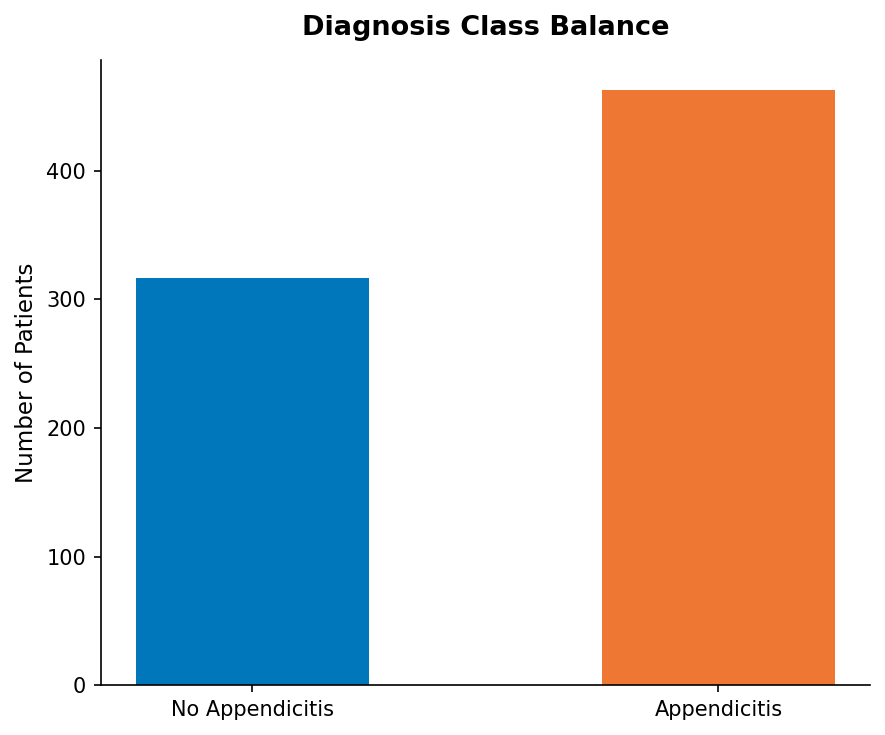

In [54]:
# First visualize general class imbalance
fig, ax = plt.subplots()

ax.bar(data["labels"].value_counts().index,
       data["labels"].value_counts().values,
       color=['#EE7733', '#0077BB'], width=0.5)
ax.set_xticks([0, 1], ['No Appendicitis', 'Appendicitis'])
ax.set_ylabel("Number of Patients")
ax.set_title("Diagnosis Class Balance")

plt.show()

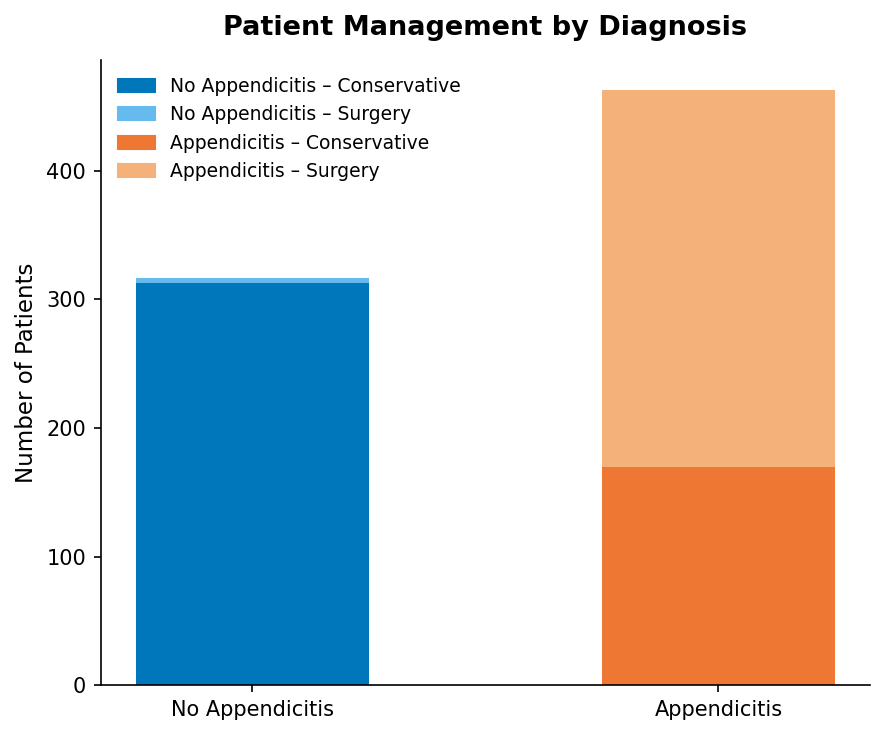

In [55]:
# Show inter-diagnosis class imbalance
counts = data.groupby(['labels', 'management_label']).size().unstack(fill_value=0)
counts.index = ['No Appendicitis', 'Appendicitis']
counts.columns = ['Conservative', 'Surgery']

fig, ax = plt.subplots()
x = np.arange(len(counts))

for i, diagnosis in enumerate(counts.index):
    conservative = counts.loc[diagnosis, 'Conservative']
    surgery = counts.loc[diagnosis, 'Surgery']
    ax.bar(x[i], conservative, width=0.5, color=DIAG_COLORS[diagnosis]['Conservative'])
    ax.bar(x[i], surgery, width=0.5, bottom=conservative, color=DIAG_COLORS[diagnosis]['Surgery'])

ax.set_title('Patient Management by Diagnosis')
ax.set_ylabel('Number of Patients')
ax.set_xticks(x, counts.index)
ax.legend(handles=[
    mpatches.Patch(color='#0077BB', label='No Appendicitis – Conservative'),
    mpatches.Patch(color='#66BBEE', label='No Appendicitis – Surgery'),
    mpatches.Patch(color='#EE7733', label='Appendicitis – Conservative'),
    mpatches.Patch(color='#F4B27A', label='Appendicitis – Surgery'),
], loc='upper left')

plt.show()

In [ ]:
# no appendicitis conservative >> no appendicitis surgery, appendicitis surgery >> appendicitis conservative
# Need to expand the minority datasets using SMOTE